# AstroCLIMB - Baseline Evaluation (Thinking-Prioritized, Whole Train 10k)
**Goal:** Zero-shot classification on 3 heterogeneous pair_types `TXT-IMG / IMG-IMG / TXT-TXT` without giving labels to model. Evaluate `whole train 10k` under 9h via batch inference. Metrics + viz + `submission.csv`.

### Priority List (Kaggle T4 x2 16GB, 9h budget)
| P | Model | Total/Active | Q4 VRAM | Type | Notes |
|---|---|---|---|---|---|
| **1** | **Qwen3-VL-8B-Thinking** `Qwen/Qwen3-VL-8B-Thinking` | 8B dense | 6.1GB needs 12GB | **Thinking** | Strongest single-T4, MathVista 79-80, DocVQA 95.3. **Start here**. |
| 2 | InternVL3.5-8B CascadeRL | 8.5B | 5.7GB Q4 | Instruct | Backup reasoning, MMMU 73.4 |
| 3 | Qwen3-VL-4B-Thinking | 4.4B | 3.3GB | Thinking | Fastest thinking, 6GB, if 8B OOM/time |
| 4 | Gemma3-12B-it | 12B | 8GB Q4 | Instruct | 128K, SigLIP |
| 5 | GLM-4.1V-9B-Thinking | 9B | 6GB | Thinking | beats 72B on 18 tasks, chart heavy |
| 6 | Kimi-VL-A3B-Thinking-2506 | 16B/3B MoE | 24GB Q4 | Thinking | Needs 2xT4+vLLM, stretch |

**Selected for this notebook:** `P1 Qwen3-VL-8B-Thinking` (change `MODEL_ID` to try others). Instruct variant also supported via `ENABLE_THINKING=False`.

**Classes (order matters for submission):** `same_figure, same_paper, related_papers, unrelated_papers` - model infers from content only, no DOI metadata.


In [1]:
# --- 1. Setup + Kaggle-ready install (run once, auto-restart if needed) ---
import os, json, time, re, gc, base64, sys, subprocess, importlib
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("NO GPU - Kaggle: Settings -> Accelerator -> GPU T4 x2 -> Save Version & Rerun")
import transformers
print(f"transformers {transformers.__version__}")
# Auto-fix bitsandbytes missing (your log: ImportError bitsandbytes>=0.46.1 at 194.2s)
try:
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} OK")
except ImportError:
    print("bitsandbytes missing, installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.46.1"])
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} installed")
# Qwen3-VL config check (needs git transformers)
try:
    from transformers.models.qwen3_vl.configuration_qwen3_vl import Qwen3VLConfig
    print("Qwen3-VL config OK")
except Exception as e:
    print(f"Qwen3-VL not supported ({e}), installing transformers from source...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/huggingface/transformers.git", "accelerate"])
    print("Installed git transformers - RESTART kernel now: Kernel -> Restart & Clear Output, then rerun")
    raise SystemExit("Restart required")


torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM: 15.6 GB
transformers 5.0.0
bitsandbytes missing, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 40.6 MB/s eta 0:00:00
bitsandbytes 0.50.2 installed
Qwen3-VL config OK


In [2]:
# --- 2. Data loading (Kaggle competitions path, train-only) ---
train = pd.read_csv("/kaggle/input/competitions/astroclimb/train.csv")
print(f"train {train.shape}")
print(train.columns.tolist())
display(train.head(2))
label_cols = ["same_figure","same_paper","related_papers","unrelated_papers"]
train["label"] = train[label_cols].idxmax(axis=1)
train["label_id"] = train["label"].map({c:i for i,c in enumerate(label_cols)})
print(train["label"].value_counts())
print(train[label_cols].sum())


train (10000, 7)
['id', 'same_figure', 'same_paper', 'related_papers', 'unrelated_papers', 'obj_1', 'obj_2']


,id,same_figure,same_paper,related_papers,unrelated_papers,obj_1,obj_2
0,0,1,0,0,0,Distribution of the RVs for TOI-2046b in the t...,iVBORw0KGgoAAAANSUhEUgAACVYAAAZUCAIAAACPYVwUAA...
1,1,1,0,0,0,Vertical structures of the Martian background ...,iVBORw0KGgoAAAANSUhEUgAABwgAAAQ2CAIAAACoaX6RAA...


label
same_paper          3000
related_papers      3000
unrelated_papers    3000
same_figure         1000
Name: count, dtype: int64
same_figure         1000
same_paper          3000
related_papers      3000
unrelated_papers    3000
dtype: int64


In [3]:
# --- 3. Helpers: detect image vs text + decode (train only) ---
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200:
        return False
    return s.strip().startswith("iVBORw0KGgo")  # PNG base64 header (JPEG would be /9j/)

def convert_str_to_PIL(img_str):
    return Image.open(BytesIO(base64.b64decode(img_str))).convert("RGB")

train["obj_1_is_img"] = train["obj_1"].apply(is_image_str)
train["obj_2_is_img"] = train["obj_2"].apply(is_image_str)
train["pair_type"] = train.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
print(train["pair_type"].value_counts())


pair_type
TXT-IMG    4000
IMG-IMG    3000
TXT-TXT    3000
Name: count, dtype: int64


In [4]:
# --- 3b. Balanced sampler for 5-7h session (per-class + pairwise per class) ---
# 5-7h = 1500-2100 samples at 12s/it. Choose 450/class => 1800 total = ~6.3h (center)
# same_figure only has TXT-IMG (1000 total), so it will be 450 TXT-IMG / 0 others. Others: 150 per pair_type.
def sample_balanced(df, n_per_class=450, seed=42):
    import pandas as pd
    assert n_per_class % 3 == 0, "n_per_class must be divisible by 3 for 3-type classes"
    parts = []
    for label in ["same_figure","same_paper","related_papers","unrelated_papers"]:
        sub = df[df["label"]==label]
        if label == "same_figure":
            # Only TXT-IMG exists for same_figure
            parts.append(sub[sub["pair_type"]=="TXT-IMG"].sample(n=n_per_class, random_state=seed))
        else:
            per_pair = n_per_class // 3
            for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
                g = sub[sub["pair_type"]==pt]
                if len(g) < per_pair:
                    print(f"Warning: {label} {pt} has {len(g)} < {per_pair}, taking all")
                    parts.append(g)
                else:
                    parts.append(g.sample(n=per_pair, random_state=seed))
    bal = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return bal

train_bal = sample_balanced(train, n_per_class=450, seed=42)
print(f"train_bal {train_bal.shape} (target 1800 = 450*4)")
print(train_bal["label"].value_counts())
print(pd.crosstab(train_bal["label"], train_bal["pair_type"]))
print(f"Estimated time: {len(train_bal)*12.5/3600:.1f}h at 12.5s/it")


train_bal (1800, 12) (target 1800 = 450*4)
label
unrelated_papers    450
related_papers      450
same_paper          450
same_figure         450
Name: count, dtype: int64
pair_type         IMG-IMG  TXT-IMG  TXT-TXT
label                                      
related_papers        150      150      150
same_figure             0      450        0
same_paper            150      150      150
unrelated_papers      150      150      150
Estimated time: 6.2h at 12.5s/it


### 4. Task (multi-class, single-label, symmetrical)
Inputs = pairs of objects: `two figures` / `figure + caption` / `two captions`. Exactly **one** label per pair, relation is symmetrical (A vs B == B vs A).

- **same_figure**: two objects are from the SAME scientific figure (only for figure+caption pairs)
- **same_paper**: same paper (same DOI), different figures
- **related_papers**: one DOI cites the other
- **unrelated_papers**: none of the above

Train has only `obj_1, obj_2` + 4 one-hot label cols -> model must infer DOI/citation **from content only** (no metadata). System prompt below is **descriptive**, not hard constraints; test hood unknown so we do not mask labels.


In [5]:
# Descriptive prompt - no metadata, infer from content only (no DOI leaked, no hard same_figure constraint)
SYSTEM_PROMPT = """You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.

Base your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.
Output ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation.
"""

def build_user_content(row):
    parts = []
    for col, name in [("obj_1","Object A"), ("obj_2","Object B")]:
        s = row[col]
        if row[f"{col}_is_img"]:
            parts.append({"name": name, "is_img": True, "pil": convert_str_to_PIL(s)})
        else:
            txt = str(s)[:2000]
            parts.append({"name": name, "is_img": False, "text": txt})
    return parts

print(SYSTEM_PROMPT[:400])
print(build_user_content(train.iloc[0])[0].keys())


You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned ve
dict_keys(['name', 'is_img', 'text'])


In [6]:
# --- 5. Model loading (kaggle-ready, OOM-safe) ---
from transformers import AutoProcessor
import torch
try:
    from transformers import Qwen3VLForConditionalGeneration
    ModelClass = Qwen3VLForConditionalGeneration
    print("Using Qwen3VLForConditionalGeneration")
except ImportError:
    from transformers import AutoModel
    ModelClass = AutoModel
    print("Fallback AutoModel")

MODEL_ID = "Qwen/Qwen3-VL-8B-Thinking"
ENABLE_THINKING = True
BATCH_SIZE = 1
MAX_NEW_TOKENS = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_ID} Thinking={ENABLE_THINKING} batch={BATCH_SIZE} max_tokens={MAX_NEW_TOKENS} on {device}")
if device=="cpu":
    raise SystemExit("STOP - Enable GPU T4 x2")
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print("Processor loaded")
# Try 4-bit first (5GB), fallback to bf16 sharded (8GB per GPU) if bitsandbytes fails
try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    model = ModelClass.from_pretrained(MODEL_ID, device_map="auto", quantization_config=bnb_config, max_memory={0:"13GB", 1:"13GB"}, trust_remote_code=True)
    print("Model loaded 4-bit", type(model).__name__)
except Exception as e:
    print(f"4-bit failed ({e}), trying bf16 sharded")
    model = ModelClass.from_pretrained(MODEL_ID, dtype="bfloat16", device_map="auto", max_memory={0:"13GB", 1:"13GB"}, trust_remote_code=True)
    print("Model loaded bf16 sharded", type(model).__name__)
model.eval()
print("Has generate:", hasattr(model, 'generate'))


Using Qwen3VLForConditionalGeneration
Loading Qwen/Qwen3-VL-8B-Thinking Thinking=True batch=1 max_tokens=32 on cuda


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

Model loaded 4-bit Qwen3VLForConditionalGeneration
Has generate: True


In [7]:
def build_messages_batch(df_batch):
    messages_list = []
    for _, row in df_batch.iterrows():
        parts = build_user_content(row)  # uses only obj_1/obj_2 + is_img
        content = [{"type": "text", "text": SYSTEM_PROMPT + "\n"}]
        for p in parts:
            if p["is_img"]:
                content.append({"type": "image", "image": p["pil"]})
                content.append({"type": "text", "text": "\n" + p["name"] + ": [Figure image]"})
            else:
                content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
        content.append({"type": "text", "text": "\nAnswer with one label:"})
        messages_list.append([{"role": "user", "content": content}])
    return messages_list


In [8]:
# --- 6b. Batched inference (OOM-safe, whole train 10k) ---
import re
from tqdm import tqdm
LABELS = label_cols
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)
def parse_label(text):
    m = label_pattern.search(text.lower())
    return m.group(1).lower() if m else "unrelated_papers"
def predict_batch(df, batch_size=BATCH_SIZE, save_every=1000, save_path="preds_train.npy"):
    preds = []
    import torch
    for i in tqdm(range(0, len(df), batch_size), desc="Infer"):
        batch = df.iloc[i:i+batch_size]
        messages_list = build_messages_batch(batch)
        texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True, enable_thinking=ENABLE_THINKING) if "qwen3" in MODEL_ID.lower() else processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in messages_list]
        batch_preds = []
        for j, (msgs, txt) in enumerate(zip(messages_list, texts)):
            images = []
            for turn in msgs:
                for part in turn["content"]:
                    if part.get("type") == "image" and "image" in part:
                        im = part["image"]
                        im.thumbnail((448,448))
                        images.append(im)
            images = images if images else None
            inputs = processor(text=[txt], images=images, padding=True, return_tensors="pt")
            # move to device (BatchFeature or dict)
            try:
                inputs = inputs.to(model.device)
            except Exception:
                inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k,v in inputs.items()}
            input_len = inputs["input_ids"].shape[1] if "input_ids" in inputs else inputs.input_ids.shape[1]
            # generation flags: do_sample=False ignores temperature/top_p, so omit them
            gen_kwargs = {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": False, "use_cache": True}
            if ENABLE_THINKING:
                gen_kwargs.update({"temperature": 0.6, "top_p": 0.95, "do_sample": True})
            try:
                with torch.no_grad():
                    out = model.generate(**inputs, **gen_kwargs)
                decoded = processor.batch_decode(out[:, input_len:], skip_special_tokens=True)[0]
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"OOM at {i+j}, clearing cache")
                    torch.cuda.empty_cache()
                    decoded = "unrelated_papers"
                else: raise
            if "<think>" in decoded:
                decoded = decoded.split("</think>")[-1]
            pred = parse_label(decoded)
            batch_preds.append(pred)
        preds.extend(batch_preds)
        if (i // batch_size + 1) % (save_every // batch_size) == 0:
            np.save(save_path, np.array(preds))
            print(f"Checkpoint {len(preds)}/{len(df)} saved")
            torch.cuda.empty_cache(); gc.collect()
        if time.time() - start_time > 6.5*3600:
            print("6.5h (5-7h test) reached - stopping early")
            break
    return np.array(preds)
start_time = time.time()
print("Starting BALANCED inference (1800 = 450/class, ~6.3h) - batch", BATCH_SIZE, "thinking", ENABLE_THINKING, f"max_tokens {MAX_NEW_TOKENS}")
preds_train = predict_batch(train_bal, batch_size=BATCH_SIZE, save_path="preds_train.npy")
print(f"Done {len(preds_train)} in {(time.time()-start_time)/3600:.2f}h")
np.save("preds_train_bal_final.npy", preds_train)
print(preds_train[:10])


Starting BALANCED inference (1800 = 450/class, ~6.3h) - batch 1 thinking True max_tokens 32


Infer:   0%|          | 0/1800 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(
Infer:  56%|█████▌    | 999/1800 [3:29:42<2:09:30,  9.70s/it]

Checkpoint 1000/1800 saved


Infer: 100%|██████████| 1800/1800 [6:21:19<00:00, 12.71s/it]

Done 1800 in 6.36h
['unrelated_papers' 'unrelated_papers' 'unrelated_papers'
 'unrelated_papers' 'unrelated_papers' 'unrelated_papers'
 'unrelated_papers' 'unrelated_papers' 'unrelated_papers' 'same_figure']


In [9]:
# --- 7. (Optional) Predict test for submission - skip if train-only evaluation ---
# Uncomment below only if you need submission.csv for Kaggle. Requires test.csv.
# test = pd.read_csv("/kaggle/input/competitions/astroclimb/test.csv")
# test["obj_1_is_img"] = test["obj_1"].apply(is_image_str)
# test["obj_2_is_img"] = test["obj_2"].apply(is_image_str)
# test["pair_type"] = test.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
# preds_test = predict_batch(test, batch_size=BATCH_SIZE, save_path="preds_test.npy")
# np.save("preds_test_final.npy", preds_test)
# sub = pd.DataFrame(0, index=test["id"], columns=label_cols)
# for pid, pred in zip(test["id"], preds_test):
#     sub.loc[pid, pred] = 1
# sub = sub.reset_index()
# sub.to_csv("submission.csv", index=False)
print("Train-only mode: test prediction skipped. Uncomment above to generate submission.csv")


Train-only mode: test prediction skipped. Uncomment above to generate submission.csv


In [10]:
# --- 8. Metrics (balanced 1800, not given to model) ---
y_true = train_bal["label"].values
y_pred = preds_train[:len(y_true)]
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
per_class = f1_score(y_true, y_pred, average=None, labels=label_cols, zero_division=0)
print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f} on balanced 1800")
print("Per-class F1:", dict(zip(label_cols, per_class.round(4))))
print(classification_report(y_true, y_pred, target_names=label_cols, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=label_cols)
cm_df = pd.DataFrame(cm, index=[f"true:{c}" for c in label_cols], columns=[f"pred:{c}" for c in label_cols])
display(cm_df)
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train_bal["pair_type"]==pt
    if mask.sum()==0: continue
    mf1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
    print(f"{pt:8} n={mask.sum():4} macro-F1={mf1:.4f}")
    print(classification_report(y_true[mask], y_pred[mask], target_names=label_cols, digits=3, zero_division=0))
metrics = {"model": MODEL_ID, "thinking": ENABLE_THINKING, "batch": BATCH_SIZE, "balanced_n_per_class": 450, "overall": {"acc": float(acc), "macro_f1": float(macro_f1), "per_class": dict(zip(label_cols, per_class.tolist()))}, "n_train": int(len(y_true)), "time_h": float((time.time()-start_time)/3600)}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))


Overall acc=0.2456 macro-F1=0.1060 on balanced 1800
Per-class F1: {'same_figure': np.float64(0.0278), 'same_paper': np.float64(0.0), 'related_papers': np.float64(0.0), 'unrelated_papers': np.float64(0.3962)}
                  precision    recall  f1-score   support

     same_figure     0.0000    0.0000    0.0000       450
      same_paper     0.1296    0.0156    0.0278       450
  related_papers     0.0000    0.0000    0.0000       450
unrelated_papers     0.2491    0.9667    0.3962       450

        accuracy                         0.2456      1800
       macro avg     0.0947    0.2456    0.1060      1800
    weighted avg     0.0947    0.2456    0.1060      1800



,pred:same_figure,pred:same_paper,pred:related_papers,pred:unrelated_papers
true:same_figure,7,0,0,443
true:same_paper,15,0,0,435
true:related_papers,17,0,0,433
true:unrelated_papers,15,0,0,435


TXT-IMG  n= 900 macro-F1=0.0786
                  precision    recall  f1-score   support

     same_figure      0.000     0.000     0.000       150
      same_paper      0.438     0.016     0.030       450
  related_papers      0.000     0.000     0.000       150
unrelated_papers      0.166     0.980     0.284       150

        accuracy                          0.171       900
       macro avg      0.151     0.249     0.079       900
    weighted avg      0.246     0.171     0.062       900

IMG-IMG  n= 450 macro-F1=0.1241
                  precision    recall  f1-score   support

     same_figure      0.000     0.000     0.000       150
      same_paper      0.000     0.000     0.000         0
  related_papers      0.000     0.000     0.000       150
unrelated_papers      0.334     0.967     0.497       150

        accuracy                          0.322       450
       macro avg      0.084     0.242     0.124       450
    weighted avg      0.111     0.322     0.166       450

TX

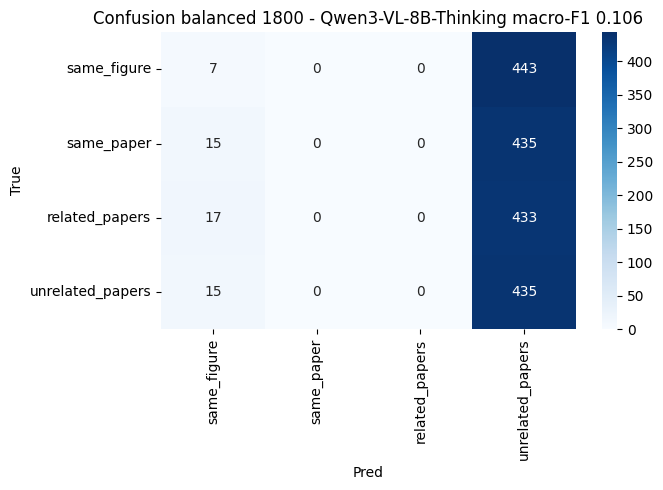

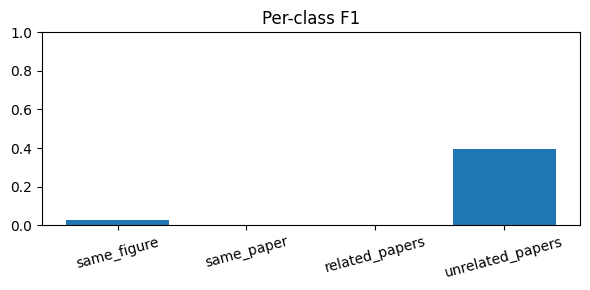

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1800 but size of corresponding boolean axis is 10000

In [11]:
# --- 9. Visualization ---
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_cols, yticklabels=label_cols)
plt.title(f"Confusion balanced 1800 - {MODEL_ID.split('/')[-1]} macro-F1 {macro_f1:.3f}")
plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.savefig("confusion.png", dpi=150); plt.show()

plt.figure(figsize=(6,3))
plt.bar(label_cols, per_class)
plt.title("Per-class F1"); plt.ylim(0,1); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("per_class_f1.png"); plt.show()

# Per pair_type F1
pts, f1s = [], []
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train["pair_type"]==pt
    f1s.append(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0))
    pts.append(pt)
plt.figure(figsize=(6,3))
plt.bar(pts, f1s)
plt.title("Macro-F1 per pair_type"); plt.ylim(0,1); plt.tight_layout(); plt.savefig("per_pair_f1.png"); plt.show()

# Caption length vs error
train_bal["correct"] = (y_true == y_pred)
train_bal["obj_1_len"] = train["obj_1"].astype(str).str.len()
plt.figure(figsize=(6,3))
sns.histplot(data=train_bal, x="obj_1_len", hue="correct", bins=30, alpha=0.6)
plt.title("Caption length vs correctness"); plt.tight_layout(); plt.savefig("len_vs_correct.png"); plt.show()
print("Saved plots")

In [ ]:
# --- 10. 6.5h guard + summary (5-7h test) ---
elapsed = (time.time()-start_time)/3600
print(f"Elapsed {elapsed:.2f}h / 6.5h budget, remaining {6.5-elapsed:.2f}h")
print(f"Model {MODEL_ID} batch {BATCH_SIZE} thinking {ENABLE_THINKING} on balanced 1800 (450/class)")
print(f"Balanced macro-F1 {macro_f1:.4f} -> full 10k would be ~34h at 12s/it, use true batch 4 or 4B model for 9h")
print("Outputs: preds_train_bal_final.npy, metrics.json, confusion.png")
